In [33]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path



In [ ]:
# Download the preprocessed data
X_train = pd.read_csv("../clean_data/X_train.csv")
X_test = pd.read_csv("../clean_data/X_test.csv")
y_train = pd.read_csv("../clean_data/y_train.csv").squeeze()
y_test = pd.read_csv("../clean_data/y_test.csv").squeeze()


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [36]:
# Construction du modèle MLP
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential()

# Couche d'entrée
model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))

# Couche cachée
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))

# Couche cachée
model.add(Dropout(0.3))
model.add(Dense(16, activation='relu'))

# Couche de sortie
model.add(Dense(1, activation='sigmoid'))

model.summary()

C:\Users\tapon\anaconda3\envs\fraud310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,441 (21.25 KB)

 Trainable params: 5,441 (21.25 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
#Compilation
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [38]:
# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

y_train_labels = y_train.squeeze().astype(int)
classes = np.unique(y_train_labels)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_labels
)

class_weights = dict(zip(classes, weights))
print(class_weights)


ValueError: classes should include all valid labels that can be in y

In [30]:
#Entraînement
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    class_weight=class_weights
)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9253 - loss: 0.2557 - val_accuracy: 0.9553 - val_loss: 0.1847
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9506 - loss: 0.2073 - val_accuracy: 0.9553 - val_loss: 0.1851
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9506 - loss: 0.2016 - val_accuracy: 0.9553 - val_loss: 0.1858
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9506 - loss: 0.2006 - val_accuracy: 0.9553 - val_loss: 0.1863
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9506 - loss: 0.1988 - val_accuracy: 0.9553 - val_loss: 0.1841
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9506 - loss: 0.1955 - val_accuracy: 0.9553 - val_loss: 0.1841
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9506 - loss: 0.1957 - val_accuracy: 0.9553 - val_loss: 0.1852
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9506 - loss: 0.1946 - val_accu

In [31]:
##  valuation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_prob = model.predict(X_test_scaled)
y_pred = (y_prob > 0.5).astype(int)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
print("ROC-AUC :", roc_auc_score(y_test, y_prob))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 841us/step
Accuracy : 0.9515
Precision : 0.0
Recall : 0.0
F1-score : 0.0
ROC-AUC : 0.5825222248105271


C:\Users\tapon\anaconda3\envs\fraud310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


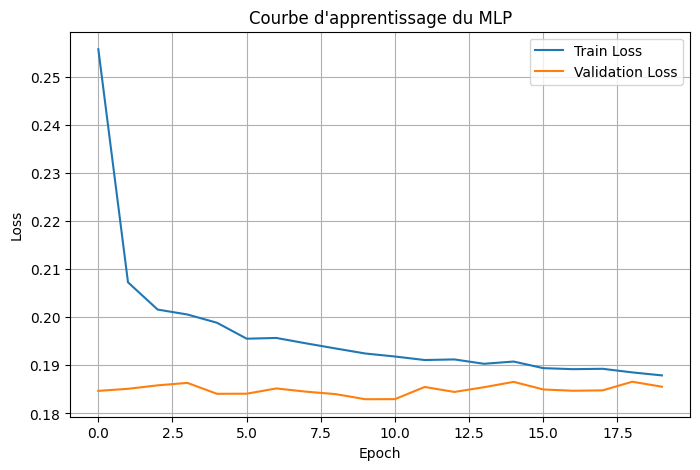

In [32]:

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Courbe d\'apprentissage du MLP')
plt.legend()
plt.grid(True)
plt.show()